# Análisis MANOVA: Efecto del Tráfico Escolar en Contaminantes Atmosféricos

## 0. Importación de Librerías y Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, f, mannwhitneyu
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv('../data_processed/dataset_wide_con_temporada.csv')
df['date'] = pd.to_datetime(df['date'])
df['clase'] = df['clase'].astype(int)

contaminantes = ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']

print(f"Dimensiones del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones del dataset: (10907, 12)

Primeras filas:


,date,anio,mes,dia,estacion,clase,CO,NO2,O3,PM10,PM2.5,temporada
0,2023-01-01 07:00:00,2023,1,1,CENTRO,0,1.040000,13.600000,16.000000,84.000000,35.00,invierno
1,2023-01-01 07:00:00,2023,1,1,NORESTE3,0,1.556333,27.100000,6.600000,140.666667,74.50,invierno
2,2023-01-01 07:00:00,2023,1,1,NOROESTE3,0,1.390000,18.666667,7.333333,57.333333,21.96,invierno
3,2023-01-01 07:00:00,2023,1,1,NORTE2,0,1.675000,29.400000,6.500000,162.500000,68.01,invierno
4,2023-01-01 07:00:00,2023,1,1,SUR,0,1.787500,43.625000,6.750000,99.250000,41.44,invierno


In [4]:
df_clean = df[contaminantes + ['clase', 'temporada', 'estacion']].dropna()
print(f"Datos después de eliminar NA: {df_clean.shape}")
print(f"\nDistribución de clase:")
print(df_clean['clase'].value_counts())
print(f"\nDistribución de temporada:")
print(df_clean['temporada'].value_counts())

Datos después de eliminar NA: (10016, 8)

Distribución de clase:
clase
0    6325
1    3691
Name: count, dtype: int64

Distribución de temporada:
temporada
otra        8295
invierno    1005
verano       716
Name: count, dtype: int64


## 1.1 Validación de Supuestos del MANOVA

### 1.1.1 Supuesto de Normalidad Multivariada (Mardia's Test)

In [5]:
def mardia_test(data):
    n, p = data.shape
    data_centered = data - data.mean(axis=0)
    S = np.cov(data.T)
    S_inv = np.linalg.inv(S)
    
    D = np.array([data_centered[i] @ S_inv @ data_centered[i] for i in range(n)])
    
    b1p = np.mean(D**3)
    b2p = np.mean(D**2)
    
    skewness_stat = n * b1p / 6
    df_skew = p * (p + 1) * (p + 2) / 6
    p_skew = 1 - chi2.cdf(skewness_stat, df_skew)
    
    kurtosis_stat = (b2p - p * (p + 2)) / np.sqrt(8 * p * (p + 2) / n)
    p_kurt = 2 * (1 - stats.norm.cdf(abs(kurtosis_stat)))
    
    return {
        'skewness': b1p,
        'skewness_stat': skewness_stat,
        'p_skewness': p_skew,
        'kurtosis': b2p,
        'kurtosis_stat': kurtosis_stat,
        'p_kurtosis': p_kurt
    }

X = df_clean[contaminantes].values
mardia_results = mardia_test(X)

print("Test de Mardia para Normalidad Multivariada")
print("=" * 50)
print(f"Asimetría multivariada (b1p): {mardia_results['skewness']:.4f}")
print(f"Estadístico chi-cuadrado: {mardia_results['skewness_stat']:.4f}")
print(f"p-valor: {mardia_results['p_skewness']:.4e}")
print(f"\nCurtosis multivariada (b2p): {mardia_results['kurtosis']:.4f}")
print(f"Estadístico Z: {mardia_results['kurtosis_stat']:.4f}")
print(f"p-valor: {mardia_results['p_kurtosis']:.4e}")

Test de Mardia para Normalidad Multivariada
Asimetría multivariada (b1p): 13407.9474
Estadístico chi-cuadrado: 22382333.4758
p-valor: 0.0000e+00

Curtosis multivariada (b2p): 103.0642
Estadístico Z: 407.0868
p-valor: 0.0000e+00


Se rechaza normalidad

### 1.1.2 Supuesto de Homogeneidad de Matrices de Covarianza (Box's M Test)

In [19]:
def box_m_test(data, group):
    groups = np.unique(group)
    n_groups = len(groups)
    p = data.shape[1]
    
    cov_matrices = []
    n_samples = []
    
    for g in groups:
        group_data = data[group == g]
        n_samples.append(len(group_data))
        cov_matrices.append(np.cov(group_data.T))
    
    n_total = sum(n_samples)
    pooled_cov = sum([(n - 1) * cov for n, cov in zip(n_samples, cov_matrices)]) / (n_total - n_groups)
    
    M = (n_total - n_groups) * np.log(np.linalg.det(pooled_cov))
    for n, cov in zip(n_samples, cov_matrices):
        M -= (n - 1) * np.log(np.linalg.det(cov))
    
    c1 = sum([1 / (n - 1) for n in n_samples]) - 1 / (n_total - n_groups)
    c = 1 - (2 * p**2 + 3 * p - 1) / (6 * (p + 1) * (n_groups - 1)) * c1
    
    chi2_stat = c * M
    df = p * (p + 1) * (n_groups - 1) / 2
    p_value = 1 - chi2.cdf(chi2_stat, df)
    
    return {
        'M': M,
        'chi2_stat': chi2_stat,
        'df': df,
        'p_value': p_value
    }

box_results = box_m_test(df_clean[contaminantes].values, df_clean['clase'].values)

print("Test de Box para Homogeneidad de Matrices de Covarianza")
print("=" * 60)
print(f"Estadístico M de Box: {box_results['M']:.4f}")
print(f"Chi-cuadrado aproximado: {box_results['chi2_stat']:.4f}")
print(f"Grados de libertad: {box_results['df']:.0f}")
print(f"p-valor: {box_results['p_value']:.4e}")

Test de Box para Homogeneidad de Matrices de Covarianza
Estadístico M de Box: 446.4583
Chi-cuadrado aproximado: 446.1970
Grados de libertad: 15
p-valor: 0.0000e+00


Las matrices de covarianza NO son homogéneas entre grupos.
Hay diferencias significativas en la estructura de varianza/covarianza.

### 1.1.3 Supuesto de Homocedasticidad Univariada (Prueba de Levene)

In [7]:
levene_results = []

for contaminante in contaminantes:
    grupo_0 = df_clean[df_clean['clase'] == 0][contaminante]
    grupo_1 = df_clean[df_clean['clase'] == 1][contaminante]
    
    stat, p_value = stats.levene(grupo_0, grupo_1)
    levene_results.append({
        'Contaminante': contaminante,
        'Estadístico': stat,
        'p-valor': p_value,
        'Homogéneo': 'Sí' if p_value > 0.05 else 'No'
    })

levene_df = pd.DataFrame(levene_results)
print("Prueba de Levene para Homogeneidad de Varianzas")
print("=" * 60)
print(levene_df.to_string(index=False))

Prueba de Levene para Homogeneidad de Varianzas
Contaminante  Estadístico      p-valor Homogéneo
          CO    32.783203 1.059979e-08        No
         NO2   126.377143 3.799436e-29        No
          O3    25.339051 4.892396e-07        No
        PM10    47.744845 5.150072e-12        No
       PM2.5     1.324149 2.498763e-01        Sí


4 de 5 contaminantes NO cumplen el supuesto de homogeneidad de varianzas.
Solo PM2.5 mantiene varianzas iguales.

### 1.1.4 Evaluación de Colinealidad entre Contaminantes

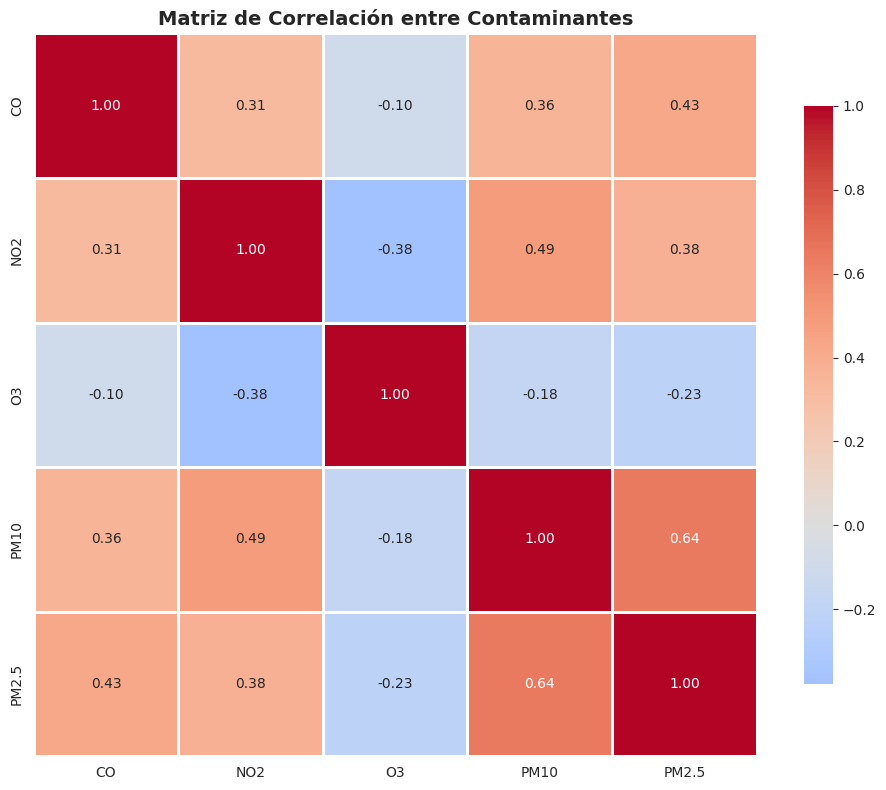


Matriz de Correlación:
             CO       NO2        O3      PM10     PM2.5
CO     1.000000  0.313131 -0.097669  0.355422  0.427446
NO2    0.313131  1.000000 -0.377608  0.492583  0.378428
O3    -0.097669 -0.377608  1.000000 -0.177137 -0.225297
PM10   0.355422  0.492583 -0.177137  1.000000  0.643516
PM2.5  0.427446  0.378428 -0.225297  0.643516  1.000000


No se encontraron correlaciones altas (|r| > 0.7)


In [8]:
corr_matrix = df_clean[contaminantes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Matriz de Correlación entre Contaminantes', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\nMatriz de Correlación:")
print(corr_matrix)

high_corr = []
for i in range(len(contaminantes)):
    for j in range(i+1, len(contaminantes)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr.append({
                'Variable 1': contaminantes[i],
                'Variable 2': contaminantes[j],
                'Correlación': corr_val
            })

if high_corr:
    print("\n\nCorrelaciones altas (|r| > 0.7):")
    print(pd.DataFrame(high_corr).to_string(index=False))
else:
    print("\n\nNo se encontraron correlaciones altas (|r| > 0.7)")

## 1.2 MANOVA Principal: Efecto de la Variable "clase"

In [20]:
formula = 'CO + NO2 + O3 + PM10 + Q("PM2.5") ~ clase'
manova = MANOVA.from_formula(formula, data=df_clean)
manova_results = manova.mv_test()

print("MANOVA: Efecto de Días con Clase vs. Sin Clase")
print("=" * 70)
print(manova_results)

MANOVA: Efecto de Días con Clase vs. Sin Clase
                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.1072 5.0000 10010.0000 16679.8726 0.0000
         Pillai's trace 0.8928 5.0000 10010.0000 16679.8726 0.0000
 Hotelling-Lawley trace 8.3316 5.0000 10010.0000 16679.8726 0.0000
    Roy's greatest root 8.3316 5.0000 10010.0000 16679.8726 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
           clase          Value  Num DF   Den DF   F Value  Pr > F
------------------------------------------------------------------
            Wilks' lambda 0.9219 5.0

### 1.2.1 Estadísticos Multivariados (Wilks, Pillai, Hotelling, Roy)

In [21]:
manova_table = manova_results.results['clase']['stat']

print("\nEstadísticos Multivariados del MANOVA:")
print("=" * 70)
print(f"\nWilks' Lambda:          {manova_table.loc['Wilks\' lambda', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Wilks\' lambda', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Wilks\' lambda', 'Pr > F']:.4e}")

print(f"\nPillai's Trace:         {manova_table.loc['Pillai\'s trace', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Pillai\'s trace', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Pillai\'s trace', 'Pr > F']:.4e}")

print(f"\nHotelling-Lawley Trace: {manova_table.loc['Hotelling-Lawley trace', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Hotelling-Lawley trace', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Hotelling-Lawley trace', 'Pr > F']:.4e}")

print(f"\nRoy's Greatest Root:    {manova_table.loc['Roy\'s greatest root', 'Value']:.6f}")
print(f"  F-statistic:          {manova_table.loc['Roy\'s greatest root', 'F Value']:.4f}")
print(f"  p-valor:              {manova_table.loc['Roy\'s greatest root', 'Pr > F']:.4e}")


Estadísticos Multivariados del MANOVA:

Wilks' Lambda:          0.921884
  F-statistic:          169.6394
  p-valor:              9.3643e-174

Pillai's Trace:         0.078116
  F-statistic:          169.6394
  p-valor:              9.3643e-174

Hotelling-Lawley Trace: 0.084735
  F-statistic:          169.6394
  p-valor:              9.3643e-174

Roy's Greatest Root:    0.084735
  F-statistic:          169.6394
  p-valor:              9.3643e-174


## 1.3 ANOVAs Univariados Complementarios

### 1.3.1 ANOVA por Contaminante

In [23]:
anova_results = []

for contaminante in contaminantes:
    formula_anova = f'{contaminante} ~ clase'
    if contaminante == 'PM2.5':
        formula_anova = 'Q("PM2.5") ~ clase'
    
    modelo = ols(formula_anova, data=df_clean).fit()
    anova_table = anova_lm(modelo, typ=2)
    
    grupo_0 = df_clean[df_clean['clase'] == 0][contaminante]
    grupo_1 = df_clean[df_clean['clase'] == 1][contaminante]
    
    anova_results.append({
        'Contaminante': contaminante,
        'F-statistic': anova_table['F'][0],
        'p-valor': anova_table['PR(>F)'][0],
        'Media Sin Clase': grupo_0.mean(),
        'Media Con Clase': grupo_1.mean(),
        'Diferencia': grupo_1.mean() - grupo_0.mean(),
        'Significativo': '***' if anova_table['PR(>F)'][0] < 0.001 else 
                        '**' if anova_table['PR(>F)'][0] < 0.01 else 
                        '*' if anova_table['PR(>F)'][0] < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)
print("ANOVAs Univariados por Contaminante")
print("=" * 100)
print(anova_df.to_string(index=False))

ANOVAs Univariados por Contaminante
Contaminante  F-statistic       p-valor  Media Sin Clase  Media Con Clase  Diferencia Significativo
          CO    64.763341  9.403732e-16         1.327996         1.447786    0.119790           ***
         NO2   833.029149 5.005041e-176        16.694039        21.722732    5.028693           ***
          O3    67.313008  2.601243e-16        12.953887        11.692044   -1.261843           ***
        PM10   144.528706  4.596440e-33        57.206936        66.230374    9.023438           ***
       PM2.5    62.980921  2.310681e-15        20.088031        22.199292    2.111260           ***


### 1.3.2 Pruebas Robustas Opcionales (Mann-Whitney U)

In [24]:
mw_results = []

for contaminante in contaminantes:
    grupo_0 = df_clean[df_clean['clase'] == 0][contaminante]
    grupo_1 = df_clean[df_clean['clase'] == 1][contaminante]
    
    stat, p_value = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
    
    mw_results.append({
        'Contaminante': contaminante,
        'U-statistic': stat,
        'p-valor': p_value,
        'Significativo': '***' if p_value < 0.001 else 
                        '**' if p_value < 0.01 else 
                        '*' if p_value < 0.05 else 'No'
    })

mw_df = pd.DataFrame(mw_results)
print("Prueba de Mann-Whitney U (No Paramétrica)")
print("=" * 70)
print(mw_df.to_string(index=False))

Prueba de Mann-Whitney U (No Paramétrica)
Contaminante  U-statistic       p-valor Significativo
          CO   10738459.5  2.186806e-11           ***
         NO2    7766882.0 2.877735e-172           ***
          O3   12812722.0  3.163314e-16           ***
        PM10    9883958.0  1.365732e-37           ***
       PM2.5   10350440.5  2.730296e-21           ***


### 1.3.3 Gráficas de Efectos Marginales

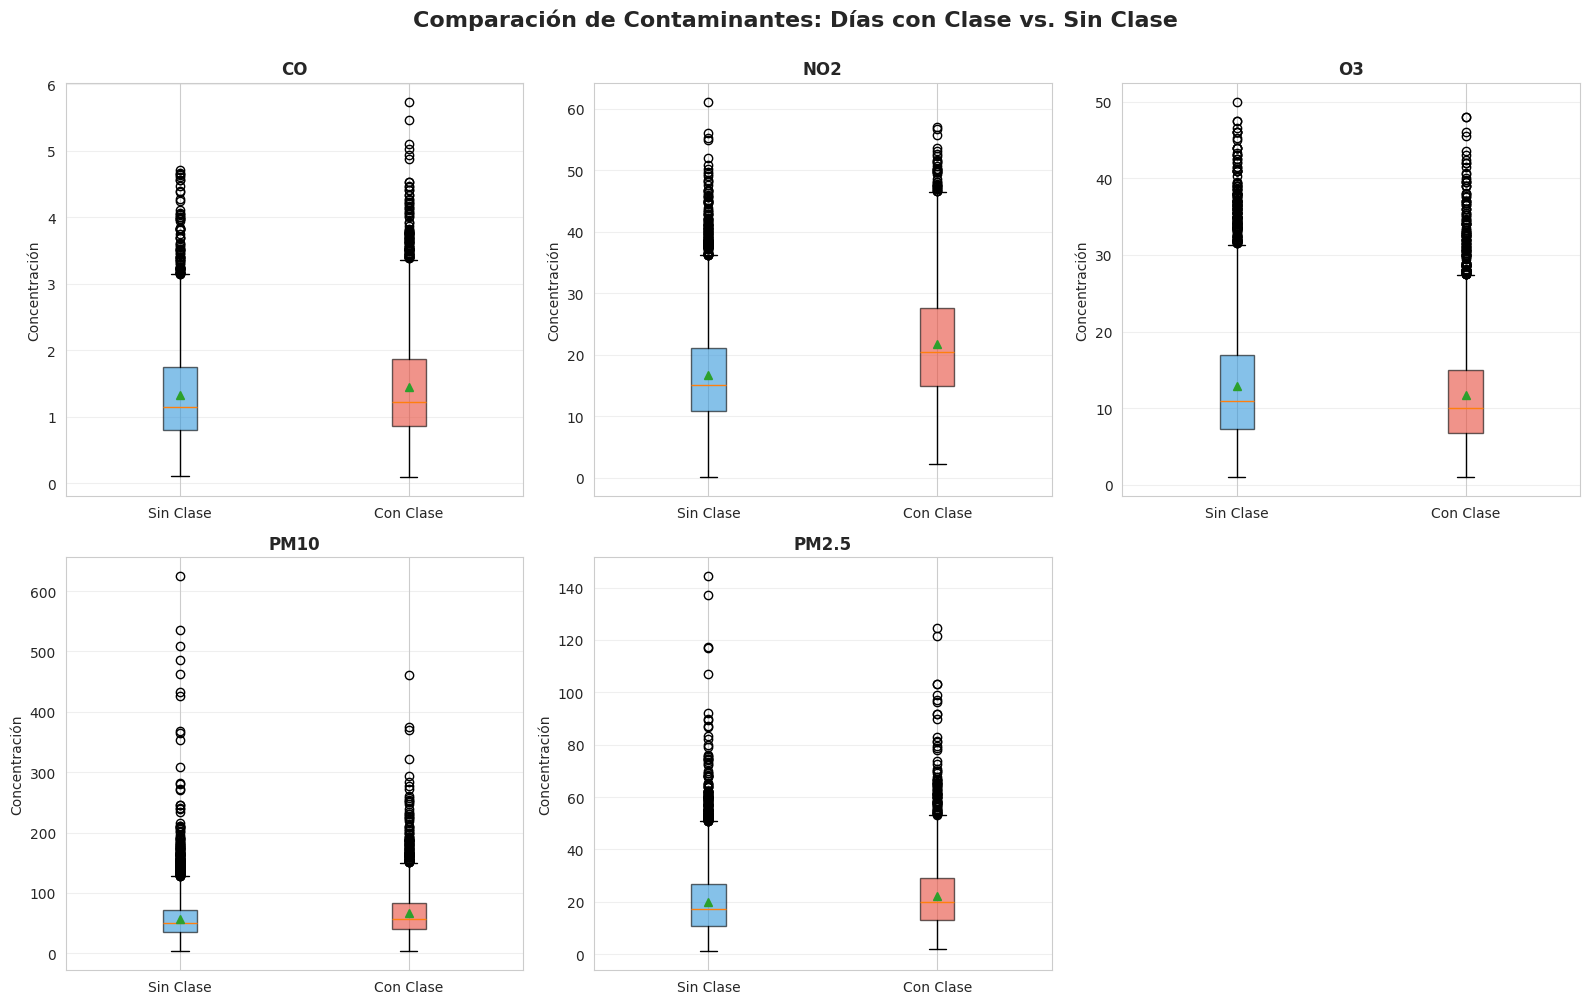

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_clean['clase_label'] = df_clean['clase'].map({0: 'Sin Clase', 1: 'Con Clase'})

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    
    data_to_plot = [
        df_clean[df_clean['clase'] == 0][contaminante].values,
        df_clean[df_clean['clase'] == 1][contaminante].values
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Sin Clase', 'Con Clase'], 
                    patch_artist=True, showmeans=True)
    
    for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{contaminante}', fontsize=12, weight='bold')
    ax.set_ylabel('Concentración', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Comparación de Contaminantes: Días con Clase vs. Sin Clase', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

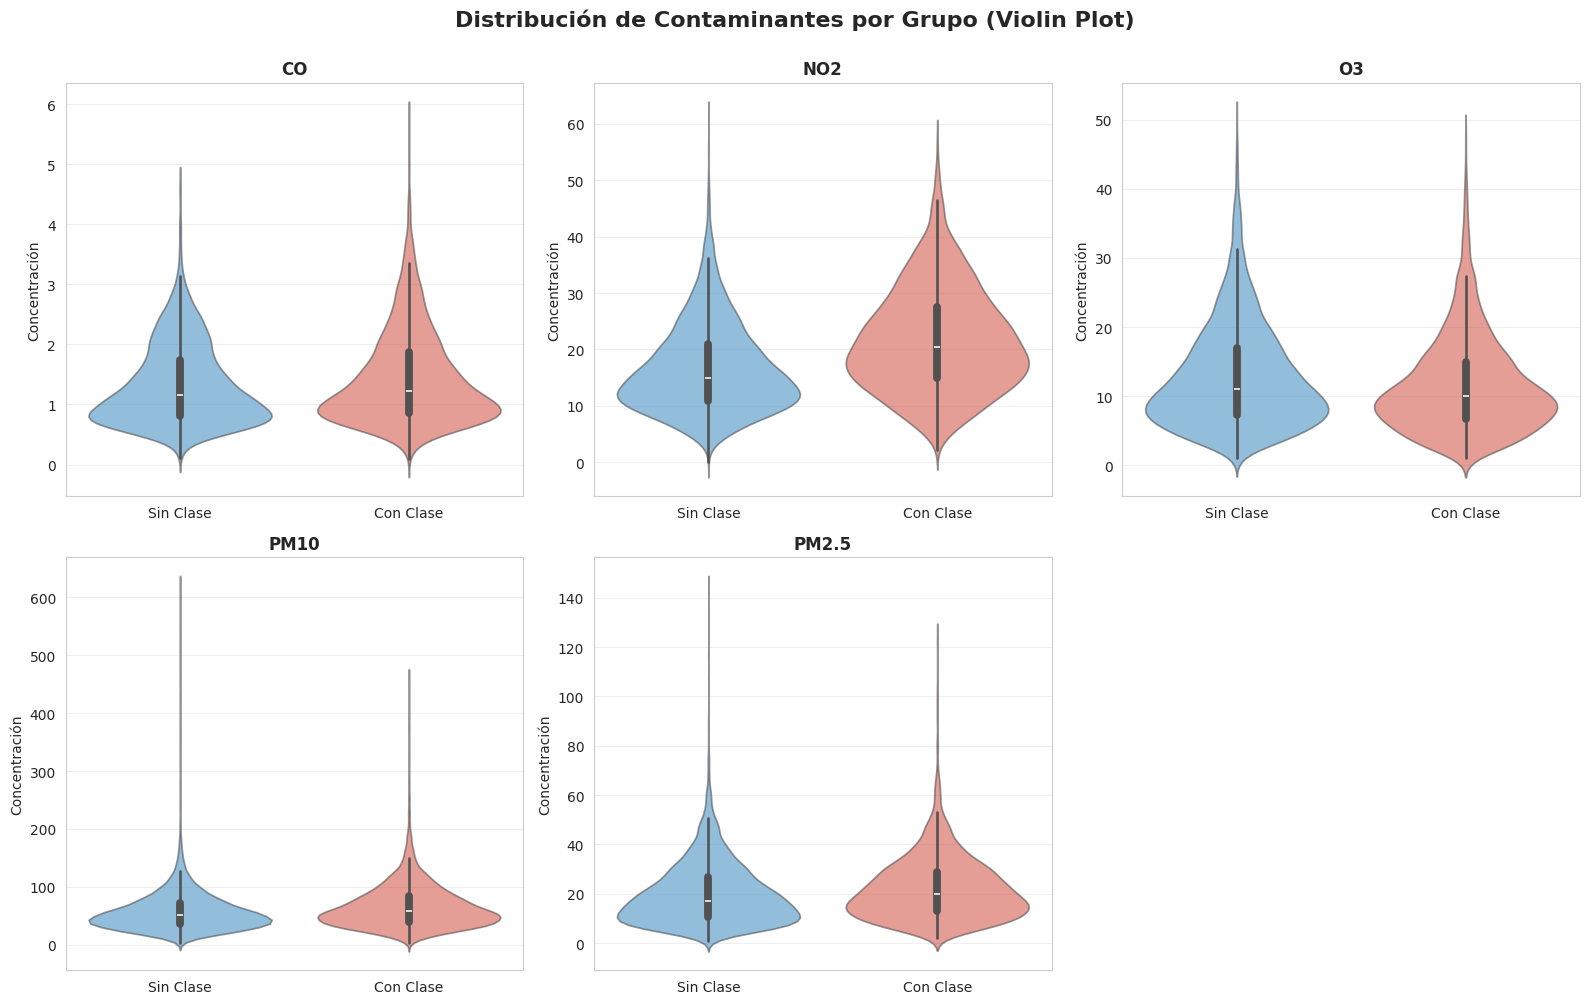

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    
    sns.violinplot(data=df_clean, x='clase_label', y=contaminante, 
                   palette=['#3498db', '#e74c3c'], ax=ax, alpha=0.6)
    
    ax.set_title(f'{contaminante}', fontsize=12, weight='bold')
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel('Concentración', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Distribución de Contaminantes por Grupo (Violin Plot)', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()

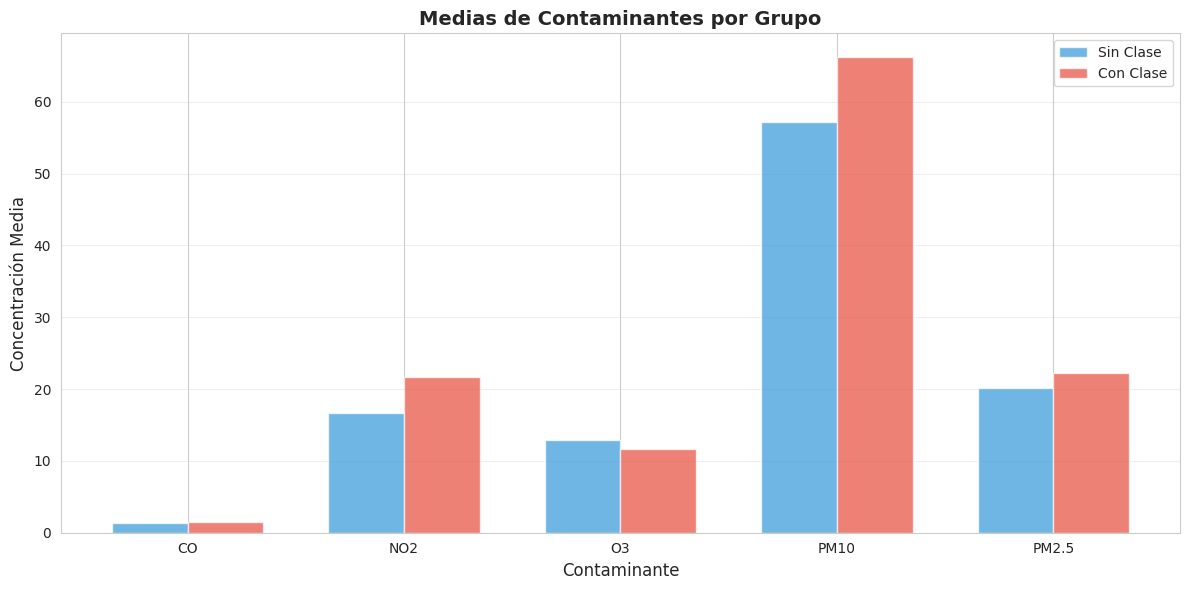

In [27]:
medias_por_grupo = df_clean.groupby('clase_label')[contaminantes].mean()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(contaminantes))
width = 0.35

bars1 = ax.bar(x - width/2, medias_por_grupo.loc['Sin Clase'], width, 
               label='Sin Clase', color='#3498db', alpha=0.7)
bars2 = ax.bar(x + width/2, medias_por_grupo.loc['Con Clase'], width, 
               label='Con Clase', color='#e74c3c', alpha=0.7)

ax.set_xlabel('Contaminante', fontsize=12)
ax.set_ylabel('Concentración Media', fontsize=12)
ax.set_title('Medias de Contaminantes por Grupo', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 1.4 MANOVA Extendido: Interacción clase × temporada

In [28]:
formula_interaccion = 'CO + NO2 + O3 + PM10 + Q("PM2.5") ~ clase * temporada'
manova_interaccion = MANOVA.from_formula(formula_interaccion, data=df_clean)
manova_results_interaccion = manova_interaccion.mv_test()

print("MANOVA con Interacción: clase × temporada")
print("=" * 70)
print(manova_results_interaccion)

MANOVA con Interacción: clase × temporada
                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.4349 5.0000 10006.0000 2600.1331 0.0000
         Pillai's trace 0.5651 5.0000 10006.0000 2600.1331 0.0000
 Hotelling-Lawley trace 1.2993 5.0000 10006.0000 2600.1331 0.0000
    Roy's greatest root 1.2993 5.0000 10006.0000 2600.1331 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
       temporada        Value   Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda 0.9230 10.0000 20012.0000  81.

In [29]:
df_clean['grupo'] = df_clean['clase_label'] + ' - ' + df_clean['temporada'].str.capitalize()

medias_interaccion = df_clean.groupby(['temporada', 'clase_label'])[contaminantes].mean()

print("\nMedias por Temporada y Clase:")
print("=" * 70)
print(medias_interaccion)


Medias por Temporada y Clase:
                             CO        NO2         O3       PM10      PM2.5
temporada clase_label                                                      
invierno  Con Clase    1.815607  26.970176   9.403523  72.817987  23.672975
          Sin Clase    1.687873  22.297872  11.011398  73.005549  24.568492
otra      Con Clase    1.455849  21.607286  12.000795  66.353216  22.540259
          Sin Clase    1.315567  16.254114  13.374039  55.581078  20.017452
verano    Con Clase    0.901323  16.862213  10.520580  56.717935  16.078478
          Sin Clase    0.921953  13.076262  11.269403  51.240880  14.108769


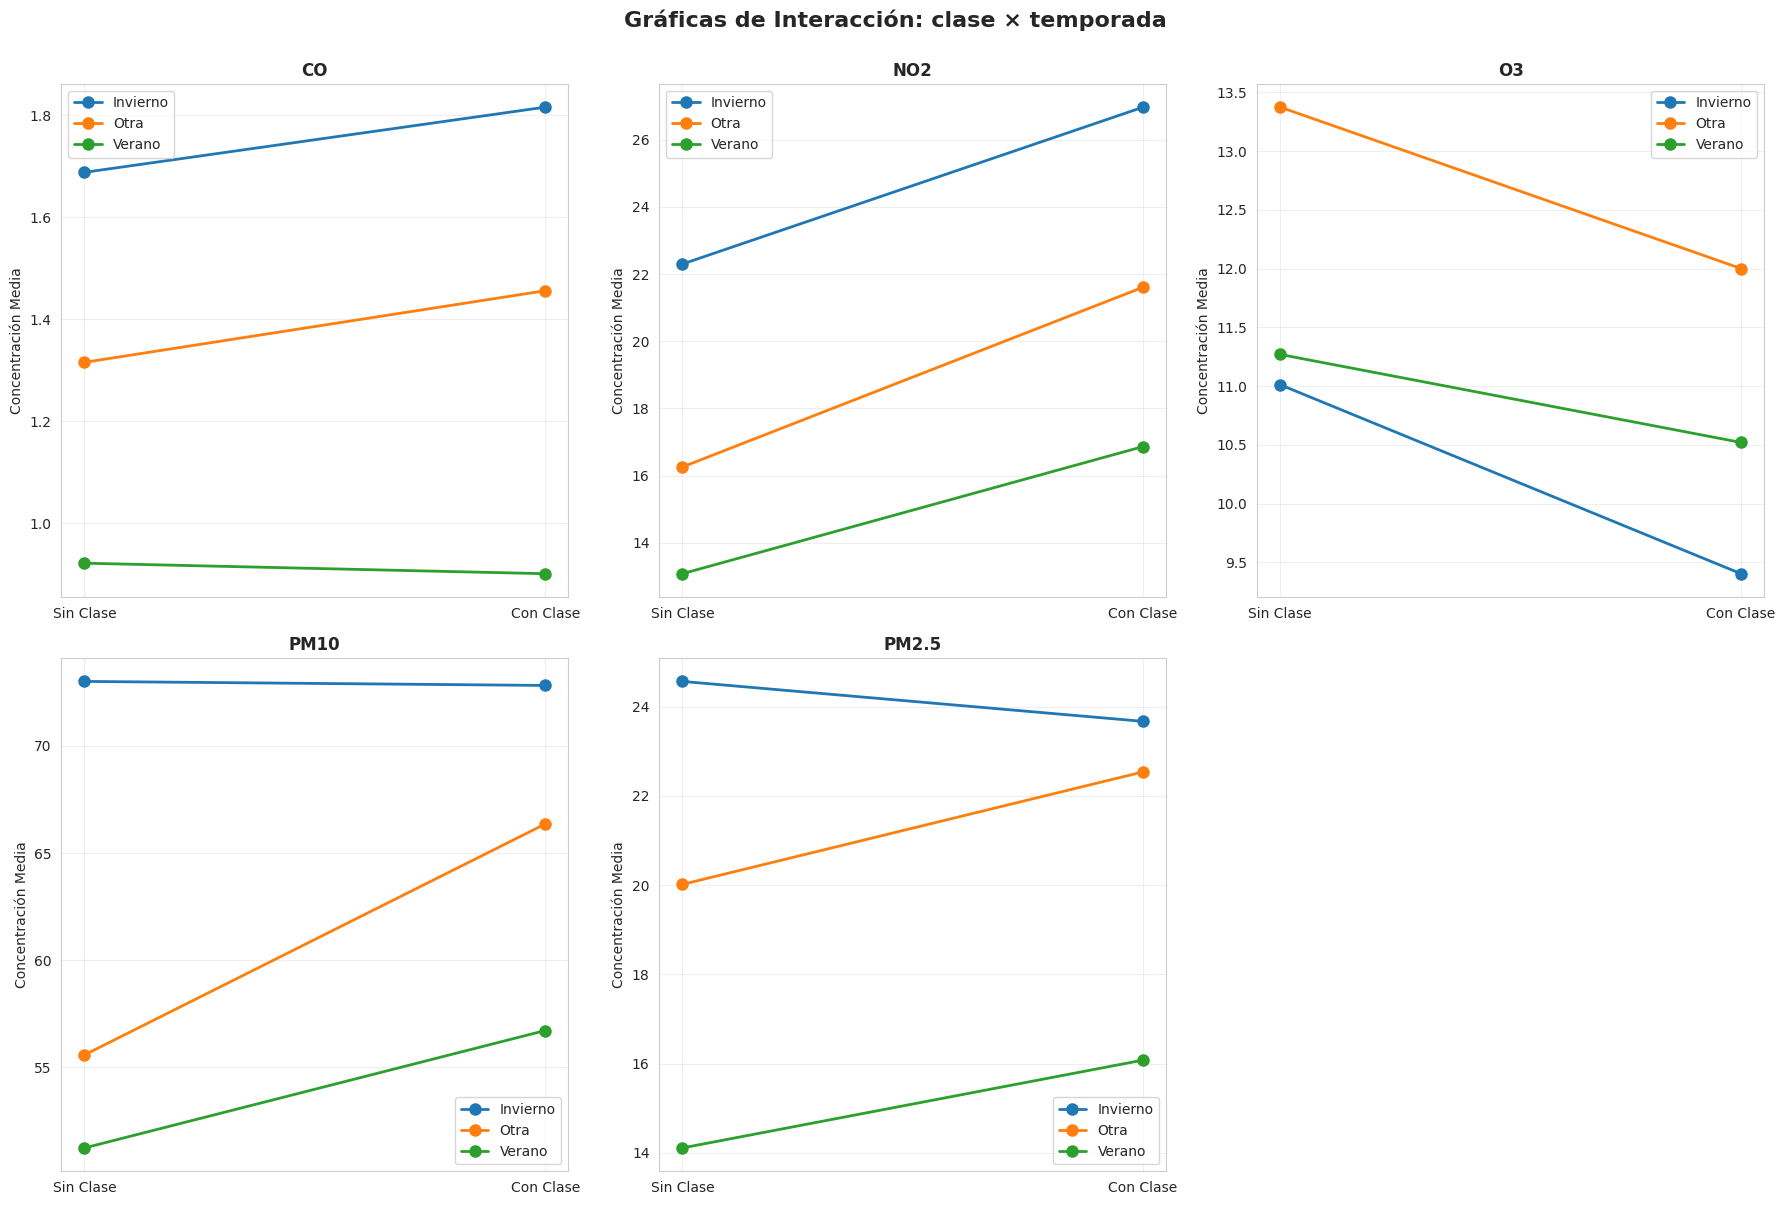

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    ax = axes[idx]
    
    for temporada in df_clean['temporada'].unique():
        data_temp = df_clean[df_clean['temporada'] == temporada]
        medias = data_temp.groupby('clase')[contaminante].mean()
        
        ax.plot([0, 1], medias.values, marker='o', linewidth=2, 
                label=temporada.capitalize(), markersize=8)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sin Clase', 'Con Clase'])
    ax.set_ylabel('Concentración Media', fontsize=10)
    ax.set_title(f'{contaminante}', fontsize=12, weight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Gráficas de Interacción: clase × temporada', 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.show()